In [1]:
# https://www.kaggle.com/datasets/rasvob/uci-poker-hand-dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rasvob/uci-poker-hand-dataset")

print("Path to dataset files:", path)


c:\Users\000010478\Downloads\Curso_MineriaMultimedia\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\000010478\.cache\kagglehub\datasets\rasvob\uci-poker-hand-dataset\versions\1


In [2]:
import pandas as pd
import numpy as np
import torch
data=pd.read_csv(path + "/poker-hand-training-true.data", header=None)
x=data.iloc[:,0:10].values
y=data.iloc[:,10].values
dataset=[(np.float32(xi),np.long(yi)) for xi, yi in zip(x, y)]
ds_train, ds_val = torch.utils.data.random_split(dataset, [int(len(dataset)*0.8), len(dataset)-int(len(dataset)*0.8)])
from torch.utils.data import DataLoader
train_loader = DataLoader(ds_train, batch_size=512, shuffle=True)
val_loader = DataLoader(ds_val, batch_size=len(ds_val), shuffle=False)

xi,yi=next(iter(train_loader))
print(xi.shape, yi.shape)

torch.Size([512, 10]) torch.Size([512])


In [3]:
data[10].value_counts().sort_index

<bound method Series.sort_index of 10
0    12493
1    10599
2     1206
3      513
4       93
5       54
6       36
7        6
9        5
8        5
Name: count, dtype: int64>

In [4]:
modelo=torch.nn.Sequential(
    torch.nn.Linear(10, 100),
    torch.nn.ReLU(),
    torch.nn.Linear(100, 60),
    torch.nn.ReLU(),
    torch.nn.Linear(60, 40),
    torch.nn.ReLU(),
    torch.nn.Linear(40, 10)
)
y_est=modelo(xi)
print(xi.shape, yi.shape, y_est.shape)
fn_error=torch.nn.CrossEntropyLoss()
optim=torch.optim.Adam(modelo.parameters(), lr=0.0001, weight_decay=0.0001)

torch.Size([512, 10]) torch.Size([512]) torch.Size([512, 10])


In [5]:
import matplotlib.pyplot as plt
from tqdm import tqdm
error_=[]
err_val=[]
patience=20
val_each=2
epochs=1000
cnt_patience=0
for epoch in range(epochs):
    tmp=[]
    modelo.train()
    for xi, yi in train_loader:
        optim.zero_grad()
        y_est=modelo(xi)
        error=fn_error(y_est, yi.long())
        error.backward()
        optim.step()
        tmp.append(error.item())
    error_.append(np.mean(tmp))
    if epoch%val_each==0:
        modelo.eval()
        for xi, yi in val_loader:
            y_est=modelo(xi)
            error=fn_error(y_est, yi.long())
            err_validacion=error.item()
        print(f"Epoch {epoch}, Error: {error_[-1]}, Validation Error: {err_validacion}")
        err_val.append((epoch, err_validacion))
        if err_validacion < error_[-1]:
            cnt_patience=0
            best=modelo.state_dict()
        else:
            cnt_patience+=1
            if cnt_patience >= patience:
                print("Se sale por early stopping")
                break
modelo.load_state_dict(best)


Epoch 0, Error: 2.1938166201114653, Validation Error: 2.043532609939575
Epoch 2, Error: 1.3318594306707383, Validation Error: 1.1930466890335083
Epoch 4, Error: 1.0619900405406952, Validation Error: 1.0629831552505493
Epoch 6, Error: 1.020096330344677, Validation Error: 1.023890495300293
Epoch 8, Error: 1.0008628860116004, Validation Error: 1.0056452751159668
Epoch 10, Error: 0.9877725198864937, Validation Error: 0.9979134202003479
Epoch 12, Error: 0.9834810271859169, Validation Error: 0.9928848743438721
Epoch 14, Error: 0.9798319295048714, Validation Error: 0.9897537231445312
Epoch 16, Error: 0.9810246646404266, Validation Error: 0.9866120219230652
Epoch 18, Error: 0.9831093087792396, Validation Error: 0.9852682948112488
Epoch 20, Error: 0.9718615263700485, Validation Error: 0.9828630089759827
Epoch 22, Error: 0.9784847438335419, Validation Error: 0.9792555570602417
Epoch 24, Error: 0.9739132940769195, Validation Error: 0.977380633354187
Epoch 26, Error: 0.9689210176467895, Validation

<All keys matched successfully>

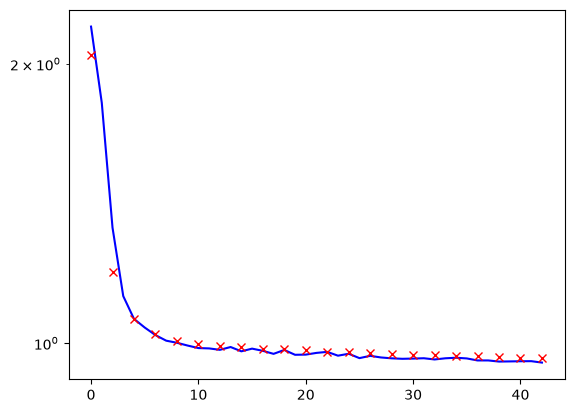

In [6]:
plt.semilogy(error_,'-b')
plt.semilogy([r[0] for r in err_val], [r[1] for r in err_val], 'xr')


In [7]:
#Verificación de la precisión en el conjunto de validación
modelo.eval()
data=pd.read_csv(path + "/poker-hand-testing.data", header=None)
x=data.iloc[:,0:10].values
y=data.iloc[:,10].values
dataset=[(np.float32(xi),np.long(yi)) for xi, yi in zip(x, y)]
test_loader = DataLoader(dataset, batch_size=len(dataset), shuffle=True)
y_pred=modelo(next(iter(test_loader))[0])

In [8]:
y_p=y_pred.argmax(dim=1).detach().numpy()
z=np.zeros((10,10), dtype=int)
for real, pred in zip(y, y_p):
    z[real, pred]+=1
pd.DataFrame(z, index=[f"Real {i}" for i in range(10)], columns=[f"Pred {i}" for i in range(10)])

,Pred 0,Pred 1,Pred 2,Pred 3,Pred 4,Pred 5,Pred 6,Pred 7,Pred 8,Pred 9
Real 0,383880,117329,0,0,0,0,0,0,0,0
Real 1,323516,98982,0,0,0,0,0,0,0,0
Real 2,36370,11252,0,0,0,0,0,0,0,0
Real 3,16268,4853,0,0,0,0,0,0,0,0
Real 4,2995,890,0,0,0,0,0,0,0,0
Real 5,1533,463,0,0,0,0,0,0,0,0
Real 6,1122,302,0,0,0,0,0,0,0,0
Real 7,182,48,0,0,0,0,0,0,0,0
Real 8,11,1,0,0,0,0,0,0,0,0
Real 9,2,1,0,0,0,0,0,0,0,0


In [9]:
data[10].value_counts().sort_index()

10
0    501209
1    422498
2     47622
3     21121
4      3885
5      1996
6      1424
7       230
8        12
9         3
Name: count, dtype: int64